In [1]:
"""Quick visualization for CMA simulations. Run in your notebook."""

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import t as t_dist
from pyhealth.datasets import get_dataloader
from pyhealth.datasets.pmlb_meta_analysis_dataset import PMLBMetaAnalysisDataset
from pyhealth.models.conformal_meta_analysis_krr import (
    ConformalMetaAnalysisModel,
)
from pyhealth.tasks.conformal_meta_analysis import (
    ConformalMetaAnalysisTask,
)


In [5]:

# ---------------------------------------------------------------------
# HKSJ baseline
# ---------------------------------------------------------------------
def hksj_interval(Y, V, alpha=0.1):
    n = len(Y)
    nu = 0.0
    for _ in range(1000):
        w = 1.0 / (V + nu)
        ate = np.sum(w * Y) / np.sum(w)
        nu_new = max(
            0.0,
            np.sum(w ** 2 * ((Y - ate) ** 2 - V)) / np.sum(w ** 2)
            + 1.0 / np.sum(w),
        )
        if abs(nu_new - nu) < 1e-8:
            break
        nu = nu_new
    w = 1.0 / (V + nu)
    ate = np.sum(w * Y) / np.sum(w)
    var_ate = np.sum((Y - ate) ** 2 * w) / ((n - 1) * np.sum(w))
    half = t_dist.ppf(1 - alpha / 2, df=n - 1) * np.sqrt(nu + var_ate)
    return float(ate - half), float(ate + half)


# ---------------------------------------------------------------------
# Single-run harness: returns CMA / HKSJ / Prior widths & coverages.
# ---------------------------------------------------------------------
def run_one(
    n_train,
    prior_error,
    effect_noise,
    alpha=0.1,
    eta=0.0,
    seed=0,
    n_samples=2000,
):
    """Run one batch and return CMA, HKSJ, and fixed-prior results."""
    dataset = PMLBMetaAnalysisDataset(
        root=f"./data/pmlb_pe{prior_error}_en{effect_noise}_s{seed}",
        pmlb_dataset_name="1196_BNG_pharynx",
        synthesize_noise=True,
        prior_error=prior_error,
        effect_noise=effect_noise,
        seed=seed,
        n_samples=n_samples,
    )
    samples = dataset.set_task(ConformalMetaAnalysisTask())
    model = ConformalMetaAnalysisModel(
        dataset=samples, alpha=alpha, eta=eta, kernel_type="gaussian"
    )

    loader = get_dataloader(samples, batch_size=n_train, shuffle=True)
    batch = next(iter(loader))

    with torch.no_grad():
        out = model(**batch)

    lo = out["interval_lower"].cpu().numpy().ravel()
    hi = out["interval_upper"].cpu().numpy().ravel()
    u = batch["true_effect"].cpu().numpy().ravel()
    Y = batch["observed_effect"].cpu().numpy().ravel()
    V = batch["variance"].cpu().numpy().ravel()
    M = batch["prior_mean"].cpu().numpy().ravel()

    finite = np.isfinite(lo) & np.isfinite(hi)
    cma_width = (
        float(np.mean(hi[finite] - lo[finite])) if finite.any() else np.nan
    )
    cma_cov = float(np.mean((u >= lo) & (u <= hi)))

    hlo, hhi = hksj_interval(Y, V, alpha=alpha)
    hksj_width = hhi - hlo
    hksj_cov = float(np.mean((u >= hlo) & (u <= hhi)))

    # Fixed-prior: use M as a point predictor with a t-interval around
    # the residual standard deviation. Serves as the "no-learning"
    # baseline for Simulation 4.
    residuals = Y - M
    resid_sd = float(np.std(residuals))
    half = t_dist.ppf(1 - alpha / 2, df=n_train - 1) * resid_sd
    prior_width = 2 * half
    prior_cov = float(np.mean(np.abs(u - M) <= half))

    return {
        "cma_width": cma_width,
        "cma_cov": cma_cov,
        "hksj_width": hksj_width,
        "hksj_cov": hksj_cov,
        "prior_width": prior_width,
        "prior_cov": prior_cov,
    }


# ---------------------------------------------------------------------
# Simulation 1: Width vs n across prior quality
# ---------------------------------------------------------------------
def simulation_1(
    n_values=(20, 50, 100, 200), seeds=(0, 1), ylim=(0, 2500)
):
    priors = {"bad": 3.0, "okay": 0.9, "good": 0.2}
    results = {label: {n: [] for n in n_values} for label in priors}

    for label, pe in priors.items():
        for n in n_values:
            for s in seeds:
                r = run_one(n, pe, effect_noise=0.5, seed=s)
                results[label][n].append(r)
                print(
                    f"[Sim1] prior={label} n={n} seed={s} "
                    f"cma={r['cma_width']:.1f} hksj={r['hksj_width']:.1f}"
                )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, (label, pe) in zip(axes, priors.items()):
        n_vals = sorted(results[label].keys())
        cma = [
            np.nanmean([r["cma_width"] for r in results[label][n]])
            for n in n_vals
        ]
        hksj = [
            np.nanmean([r["hksj_width"] for r in results[label][n]])
            for n in n_vals
        ]
        ax.plot(n_vals, cma, "-o", label="CMA", color="crimson")
        ax.plot(n_vals, hksj, "-o", label="HKSJ", color="teal")
        ax.set_xscale("log")
        ax.set_xlabel("n")
        ax.set_title(f"Simulation 1 ({label} prior)")
        ax.set_ylim(*ylim)
        ax.legend()
    axes[0].set_ylabel("interval width")
    plt.tight_layout()
    plt.savefig("simulation_1.png", dpi=150)
    plt.show()
    return results


# ---------------------------------------------------------------------
# Simulation 2: Coverage vs effect noise (CMA vs HKSJ)
# ---------------------------------------------------------------------
def simulation_2(
    noise_values=(0.0, 50.0, 100.0, 200.0, 400.0),
    n_values=(50, 200),
    seeds=(0, 1),
    alpha=0.05,
    ylim=(0.80, 1.02),
):
    results = {
        n: {noise: [] for noise in noise_values} for n in n_values
    }
    for n in n_values:
        for noise in noise_values:
            for s in seeds:
                r = run_one(
                    n, prior_error=0.2, effect_noise=noise,
                    alpha=alpha, seed=s,
                )
                results[n][noise].append(r)
                print(
                    f"[Sim2] n={n} noise={noise} seed={s} "
                    f"cma_cov={r['cma_cov']:.3f} hksj_cov={r['hksj_cov']:.3f}"
                )

    fig, axes = plt.subplots(1, len(n_values), figsize=(6 * len(n_values), 4),
                             sharey=True)
    for ax, n in zip(axes, n_values):
        noise_vals = sorted(results[n].keys())
        cma = [
            np.nanmean([r["cma_cov"] for r in results[n][noise]])
            for noise in noise_vals
        ]
        hksj = [
            np.nanmean([r["hksj_cov"] for r in results[n][noise]])
            for noise in noise_vals
        ]
        ax.plot(noise_vals, cma, "-o", label="CMA", color="crimson")
        ax.plot(noise_vals, hksj, "-o", label="HKSJ", color="teal")
        ax.axhline(1 - alpha, ls="--", color="black", alpha=0.5,
                   label=f"target {1 - alpha:.2f}")
        ax.set_xlabel("effect noise")
        size_label = "small n" if n < 100 else "large n"
        ax.set_title(f"Simulation 2 ({size_label}, n={n})")
        ax.set_ylim(*ylim)
        ax.legend()
    axes[0].set_ylabel("coverage")
    plt.tight_layout()
    plt.savefig("simulation_2.png", dpi=150)
    plt.show()
    return results


# ---------------------------------------------------------------------
# Simulation 3: Coverage with eta=0 vs eta>0
# ---------------------------------------------------------------------
def simulation_3(
    noise_values=(0.0, 100.0 , 500.0, 1000.0),
    n_values=(50, 200),
    seeds=(0, 1),
    alpha=0.05,
    ylim=(0.85, 1.02),
):
    # Compute the eta that targets ~2alpha confidence loss: eta = 2*inverfc(1/(2*(1-alpha)))^2
    # Here we just use a modest positive value (0.4015 from the paper).
    eta_values = {"eta=0": 0.0, "eta>0": 0.4015}

    results = {
        n: {name: {noise: [] for noise in noise_values}
            for name in eta_values}
        for n in n_values
    }
    for n in n_values:
        for name, eta in eta_values.items():
            for noise in noise_values:
                for s in seeds:
                    r = run_one(
                        n, prior_error=0.1, effect_noise=noise,
                        alpha=alpha, eta=eta, seed=s,
                    )
                    results[n][name][noise].append(r)
                    print(
                        f"[Sim3] n={n} {name} noise={noise} "
                        f"cov={r['cma_cov']:.3f}"
                    )

    fig, axes = plt.subplots(1, len(n_values), figsize=(6 * len(n_values), 4),
                             sharey=True)
    for ax, n in zip(axes, n_values):
        noise_vals = sorted(noise_values)
        for name, color in [("eta=0", "salmon"), ("eta>0", "purple")]:
            covs = [
                np.nanmean([r["cma_cov"] for r in results[n][name][noise]])
                for noise in noise_vals
            ]
            ax.plot(noise_vals, covs, "-o", label=name, color=color)
        ax.axhline(1 - alpha, ls="--", color="black", alpha=0.5,
                   label=f"target {1 - alpha:.2f}")
        size_label = "small n" if n < 100 else "large n"
        ax.set_xlabel("effect noise")
        ax.set_title(f"Simulation 3 ({size_label}, n={n})")
        ax.set_ylim(*ylim)
        ax.legend()
    axes[0].set_ylabel("coverage")
    plt.tight_layout()
    plt.savefig("simulation_3.png", dpi=150)
    plt.show()
    return results


# ---------------------------------------------------------------------
# Simulation 4: Width comparison vs prior quality (CMA vs HKSJ vs Prior)
# ---------------------------------------------------------------------
def simulation_4(
    prior_values=(0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0),
    n_values=(16, 200),
    seeds=(0, 1),
    alpha=0.1,
    ylim=(0, 5000),
):
    results = {
        n: {pe: [] for pe in prior_values} for n in n_values
    }
    for n in n_values:
        for pe in prior_values:
            for s in seeds:
                r = run_one(
                    n, prior_error=pe, effect_noise=0.02,
                    alpha=alpha, seed=s,
                )
                results[n][pe].append(r)
                print(
                    f"[Sim4] n={n} pe={pe} seed={s} "
                    f"cma={r['cma_width']:.1f} "
                    f"hksj={r['hksj_width']:.1f} "
                    f"prior={r['prior_width']:.1f}"
                )

    fig, axes = plt.subplots(1, len(n_values), figsize=(6 * len(n_values), 4),
                             sharey=True)
    for ax, n in zip(axes, n_values):
        pe_vals = sorted(results[n].keys())
        cma = [
            np.nanmean([r["cma_width"] for r in results[n][pe]])
            for pe in pe_vals
        ]
        hksj = [
            np.nanmean([r["hksj_width"] for r in results[n][pe]])
            for pe in pe_vals
        ]
        prior = [
            np.nanmean([r["prior_width"] for r in results[n][pe]])
            for pe in pe_vals
        ]
        ax.plot(pe_vals, cma, "-o", label="CMA", color="crimson")
        ax.plot(pe_vals, hksj, "-o", label="HKSJ", color="teal")
        ax.plot(pe_vals, prior, "-o", label="Prior", color="olive")
        size_label = "small n" if n < 100 else "large n"
        ax.set_xlabel("prior error")
        ax.set_title(f"Simulation 4 ({size_label}, n={n})")
        ax.set_ylim(*ylim)
        ax.legend()
    axes[0].set_ylabel("interval width")
    plt.tight_layout()
    plt.savefig("simulation_4.png", dpi=150)
    plt.show()
    return results

In [ ]:
print("Simulation 1")
sim1 = simulation_1()

In [ ]:
print("Simulation 2")
sim2 = simulation_2()

Simulation 3
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.1_en0.0_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\dbc14fd7-741c-52eb-aa51-660909149833
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\dbc14fd7-741c-52eb-aa51-660909149833\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\dbc14fd7-741c-52eb-aa51-660909149833\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\dbc14fd7-741c-52eb-aa51-660909149833\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbb

C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:8: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:9: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)
C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:18: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:19: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)
C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:8: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:9: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)
C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:18: Runtim

Saved PMLB metadata to ./data/pmlb_pe0.1_en500.0_s0\pmlb_meta_analysis_noisy-metadata-pyhealth.csv
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.1_en500.0_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\a0c7721b-9dd9-5416-9792-aedc37dcf469
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\a0c7721b-9dd9-5416-9792-aedc37dcf469\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\a0c7721b-9dd9-5416-9792-aedc37dcf469\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Applying task transformations on data with 1 workers...
No cached event dataframe found. Creating: C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\a0c7721b-9d

  0%|          | 0/2000 [00:00<?, ?it/s]

Rank 0 inferred the following `['bytes']` data format.


...

[Sim3] n=200 eta=0 noise=100.0 cov=0.965
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.1_en100.0_s1 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-

C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:8: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:9: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)
C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:18: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:19: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)


[Sim3] n=200 eta>0 noise=0.0 cov=0.950
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.1_en100.0_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\1df6a36a-c128-5678-b8d1-d4d387fa7c85
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\1df6a36a-c128-5678-b8d1-d4d387fa7c85\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\1df6a36a-c128-5678-b8d1-d4d387fa7c85\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\1df6a36a-c128-5678-b8d1-d4d387fa7c85\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8e

C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:8: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:9: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)
C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:18: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\bdarragh\AppData\Local\Temp\ipykernel_27480\1323635509.py:19: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)


[Sim3] n=200 eta>0 noise=100.0 cov=0.965
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.1_en100.0_s1 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\bdarragh\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-

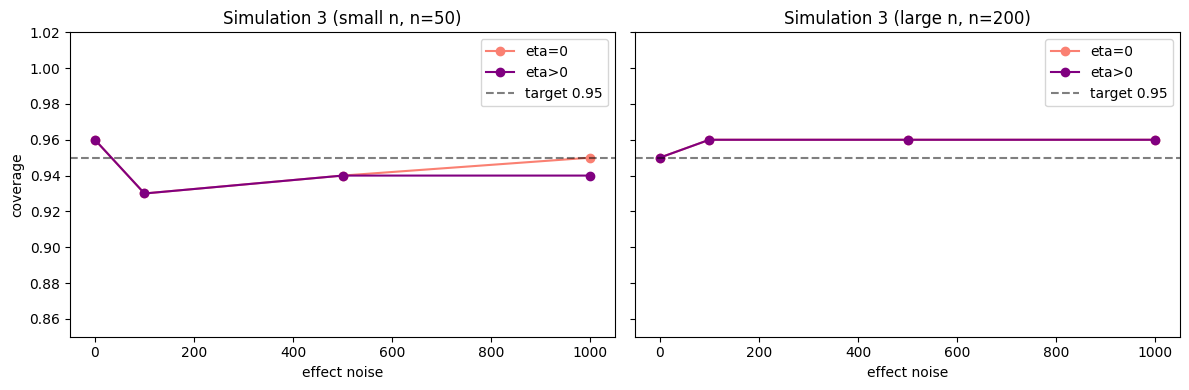

In [6]:
print("Simulation 3")
sim3 = simulation_3()

In [ ]:
print("Simulation 4")
sim4 = simulation_4()